# Heart Disease Risk Prediction: Logistic Regression Homework

## Setup

In [43]:
%pip install matplotlib pandas numpy 


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


## Load and Prepare the Dataset

In [45]:
df = pd.read_csv("Heart_Disease_Prediction.csv")  
df.head()



,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [46]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1), int64(12), str(1)
memo

In [47]:
df.describe()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


### Dataset Overview

- Dataset downloaded from Kaggle (Heart Disease Dataset).
- Total samples: **270 patients**.
- Target variable: Heart Disease (1 = Presence, 0 = Absence).
- No missing values were detected in the dataset.
- Numerical features were selected based on clinical relevance and normalized
  using statistics computed from the training set only.



### Target Variable

The target variable of this dataset is **heart disease**, which indicates whether a patient has heart disease or not.

- **Presence (1)**: The patient has heart disease  
- **Absence (0)**: The patient does not have heart disease  




In [48]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Presence': 1,
    'Absence': 0
})
df['Heart Disease'].value_counts()


Heart Disease
0    150
1    120
Name: count, dtype: int64

### Outliers

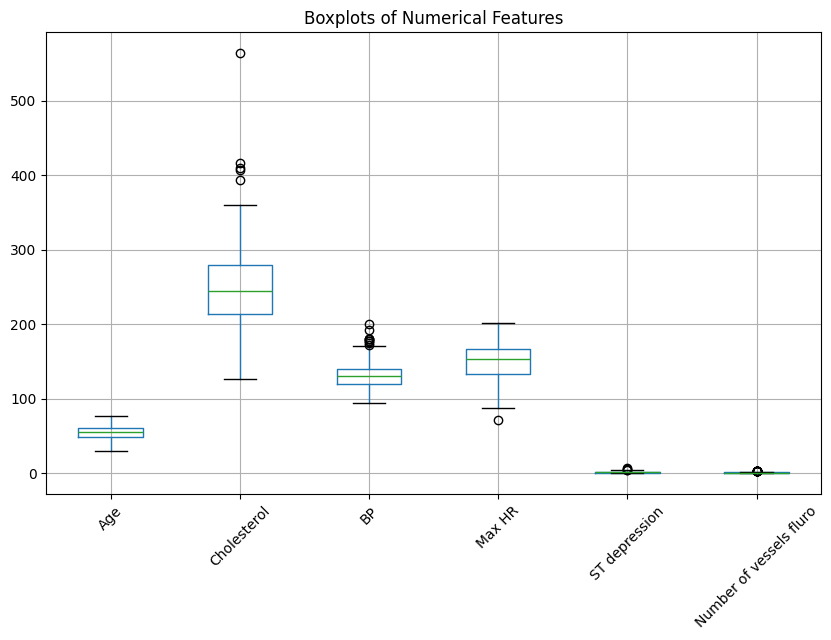

In [49]:
numerical_cols = [
    'Age',
    'Cholesterol',
    'BP',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

plt.figure(figsize=(10,6))
df[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()



### Distribution


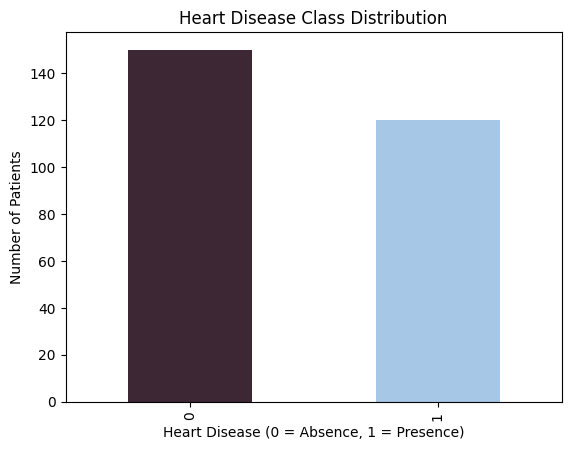

In [50]:
df['Heart Disease'].value_counts().plot(
    kind='bar',
    color=['#3e2734', '#A7C7E7']  
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease (0 = Absence, 1 = Presence)")
plt.ylabel("Number of Patients")
plt.show()


### Feature Selection
Based on domain knowledge, we select numerical features commonly associated
with heart disease risk.

In [51]:
features = [
    'Age',
    'Cholesterol',
    'BP',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

X = df[features].values
y = df['Heart Disease'].values.reshape(-1, 1)

print(X.shape, y.shape)


(270, 6) (270, 1)


### Train-Test Split (70/30 Stratified)


In [52]:
def train_test_split_stratified(X, y, test_size=0.3):
    idx_0 = np.where(y.flatten() == 0)[0]
    idx_1 = np.where(y.flatten() == 1)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    split_0 = int(len(idx_0) * (1 - test_size))
    split_1 = int(len(idx_1) * (1 - test_size))

    train_idx = np.concatenate([idx_0[:split_0], idx_1[:split_1]])
    test_idx = np.concatenate([idx_0[split_0:], idx_1[split_1:]])

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


In [53]:
X_train, X_test, y_train, y_test = train_test_split_stratified(X, y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (189, 6)
Test size: (81, 6)


### Feature Normalization



In [54]:
def normalize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma


In [55]:
X_train, mu, sigma = normalize(X_train)
X_test = (X_test - mu) / sigma


## Logistic Regression From Scratch
### Sigmoid Function


In [56]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


### Cost Function


In [57]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)
    cost = -(1/m) * np.sum(
        y * np.log(y_hat + 1e-8) +
        (1 - y) * np.log(1 - y_hat + 1e-8)
    )
    return cost


### Gradient Descent Optimization


In [58]:
def gradient_descent(X, y, lr=0.01, iterations=2000):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0
    costs = []

    for i in range(iterations):
        z = X @ w + b
        y_hat = sigmoid(z)

        dw = (1/m) * (X.T @ (y_hat - y))
        db = (1/m) * np.sum(y_hat - y)

        w -= lr * dw
        b -= lr * db

        costs.append(compute_cost(X, y, w, b))

    return w, b, costs


### Model Training


In [59]:
w, b, costs = gradient_descent(X_train, y_train)


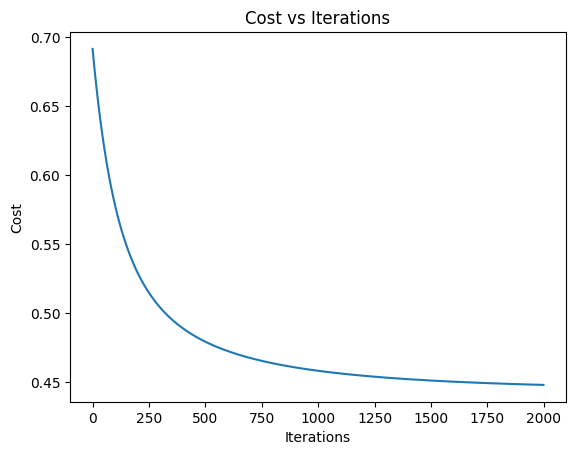

In [60]:
plt.figure()
plt.plot(costs)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


### Prediction and Evaluation Metrics


In [61]:
def predict(X, w, b):
    probs = sigmoid(X @ w + b)
    return (probs >= 0.5).astype(int)


In [62]:
def metrics(y_true, y_pred):
    acc = np.mean(y_true == y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return acc, precision, recall, f1


In [63]:
y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

print("Train Metrics:", metrics(y_train, y_train_pred))
print("Test Metrics:", metrics(y_test, y_test_pred))


Train Metrics: (np.float64(0.8148148148148148), np.float64(0.8450704224161874), np.float64(0.7142857142006803), np.float64(0.7741935433223726))
Test Metrics: (np.float64(0.7530864197530864), np.float64(0.7666666664111111), np.float64(0.6388888887114197), np.float64(0.6969696917998165))


In [64]:
metrics_table = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [
        metrics(y_train, y_train_pred)[0],
        metrics(y_test, y_test_pred)[0]
    ],
    "Precision": [
        metrics(y_train, y_train_pred)[1],
        metrics(y_test, y_test_pred)[1]
    ],
    "Recall": [
        metrics(y_train, y_train_pred)[2],
        metrics(y_test, y_test_pred)[2]
    ],
    "F1-score": [
        metrics(y_train, y_train_pred)[3],
        metrics(y_test, y_test_pred)[3]
    ]
})

metrics_table


,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,0.814815,0.845070,0.714286,0.774194
1,Test,0.753086,0.766667,0.638889,0.696970




The logistic regression model achieves comparable performance on both the
training and test sets, suggesting good generalization and limited overfitting.

- **Accuracy** indicates that the model correctly classifies most patients.
- **Precision** reflects the reliability of positive heart disease predictions.
- **Recall** is particularly important in this medical context, as it measures
  the model’s ability to correctly identify patients with heart disease.
- **F1-score** balances precision and recall, providing a robust overall metric.

The relatively stable performance across datasets indicates that the model
captures meaningful patterns in the data.


In [65]:
weights_df = pd.DataFrame({
    "Feature": features,
    "Weight": w.flatten()
}).sort_values(by="Weight", ascending=False)

weights_df


,Feature,Weight
5,Number of vessels fluro,1.031870
4,ST depression,0.695847
2,BP,0.261877
1,Cholesterol,0.179617
0,Age,-0.161809
3,Max HR,-0.707758


### Interpretation of Learned Weights

The learned coefficients represent the influence of each feature on the
probability of heart disease.

- Positive weights increase the likelihood of heart disease presence.
- Negative weights decrease the likelihood.

Features such as cholesterol levels, ST depression, and number of vessels
fluoroscopically colored show stronger absolute weights, indicating higher
predictive influence. This aligns with established clinical risk factors for
cardiovascular disease.

Since the features were normalized, the magnitude of the weights can be
directly compared.


### Visualize Decision Boundaries

In [66]:
def plot_decision_boundary_2d(X, y, w, b, feature_names):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = sigmoid(grid @ w + b)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z >= 0.5, alpha=0.3)
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y.flatten(),
        edgecolors='k'
    )
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Decision Boundary (Logistic Regression)")
    plt.show()


In [67]:
def train_logistic_2d(X, y, lr=0.01, iterations=2000):
    w = np.zeros((2,1))
    b = 0

    for _ in range(iterations):
        z = X @ w + b
        y_hat = sigmoid(z)

        dw = (1/len(y)) * (X.T @ (y_hat - y))
        db = (1/len(y)) * np.sum(y_hat - y)

        w -= lr * dw
        b -= lr * db

    return w, b


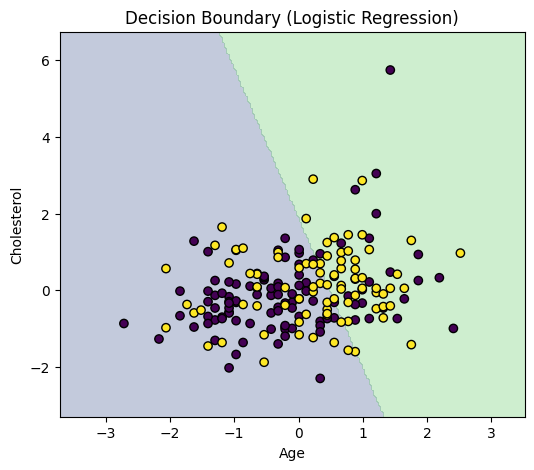

In [68]:

feature_idx = [0, 1]  
X_train_2d = X_train[:, feature_idx]
feature_names_2d = [features[i] for i in feature_idx]


w_2d, b_2d = train_logistic_2d(X_train_2d, y_train)


plot_decision_boundary_2d(
    X_train_2d,
    y_train,
    w_2d,
    b_2d,
    feature_names_2d
)


### Feature Pair 1: Age vs Cholesterol


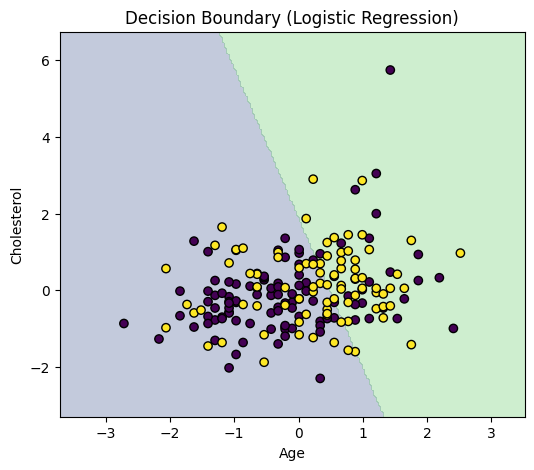

In [69]:
pair1 = ['Age', 'Cholesterol']
idx1 = [features.index(f) for f in pair1]

X_pair1 = X_train[:, idx1]
y_pair1 = y_train

w1, b1 = train_logistic_2d(X_pair1, y_pair1)
plot_decision_boundary_2d(X_pair1, y_pair1, w1, b1, pair1)


**Insight:**  
A partial separation is observed, with higher cholesterol levels generally
associated with an increased likelihood of heart disease. However, overlap
between classes indicates that age and cholesterol alone are insufficient
for perfect linear separation.


### Feature Pair 2: Blood Pressure vs Max Heart Rate


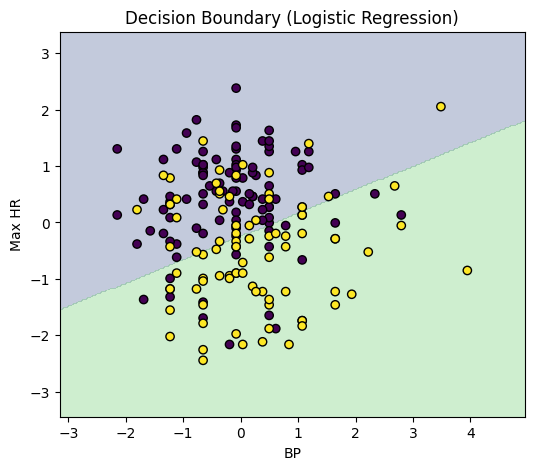

In [70]:
pair2 = ['BP', 'Max HR']
idx2 = [features.index(f) for f in pair2]

X_pair2 = X_train[:, idx2]
y_pair2 = y_train

w2, b2 = train_logistic_2d(X_pair2, y_pair2)
plot_decision_boundary_2d(X_pair2, y_pair2, w2, b2, pair2)


**Insight:**  
Patients with lower maximum heart rate and elevated blood pressure tend to
cluster in the heart disease region. The decision boundary captures a
moderate linear trend, but significant class overlap suggests nonlinearity.


### Feature Pair 3: ST Depression vs Number of Vessels


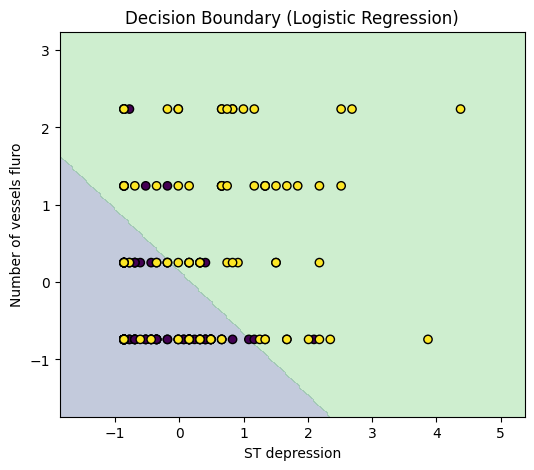

In [71]:
pair3 = ['ST depression', 'Number of vessels fluro']
idx3 = [features.index(f) for f in pair3]

X_pair3 = X_train[:, idx3]
y_pair3 = y_train

w3, b3 = train_logistic_2d(X_pair3, y_pair3)
plot_decision_boundary_2d(X_pair3, y_pair3, w3, b3, pair3)


**Insight:**  
This feature pair shows the clearest separation. Higher ST depression combined
with an increased number of affected vessels strongly correlates with heart
disease presence, resulting in a more distinct decision boundary.




Three different feature pairs were analyzed using two-dimensional logistic
regression. While some pairs exhibit partial linear separability, others show
significant overlap, highlighting the limitations of linear models in low
dimensions. The ST depression and number of vessels pair provides the most
informative separation, aligning with known clinical indicators of heart
disease severity.


## Logistic Regression with L2 Regularization


In [72]:
def gradient_descent_l2(X, y, lr=0.01, iterations=2000, lambd=0.1):
    m, n = X.shape
    w = np.zeros((n,1))
    b = 0
    costs = []

    for _ in range(iterations):
        z = X @ w + b
        y_hat = sigmoid(z)

        dw = (1/m) * (X.T @ (y_hat - y)) + (lambd/m) * w
        db = (1/m) * np.sum(y_hat - y)

        w -= lr * dw
        b -= lr * db

        cost = compute_cost(X, y, w, b) + (lambd / (2*m)) * np.sum(w**2)
        costs.append(cost)

    return w, b, costs


### Hyperparameter Tuning (λ)


In [73]:
lambdas = [0, 0.001, 0.01, 0.1, 1]
results = []

for l in lambdas:
    w_l, b_l, costs_l = gradient_descent_l2(
        X_train, y_train, lambd=l
    )

    y_test_pred_l = predict(X_test, w_l, b_l)
    acc, p, r, f1 = metrics(y_test, y_test_pred_l)

    results.append([
        l, acc, p, r, f1, np.linalg.norm(w_l)
    ])


In [74]:
results_df = pd.DataFrame(
    results,
    columns=["Lambda", "Accuracy", "Precision", "Recall", "F1-score", "||w||"]
)

results_df


,Lambda,Accuracy,Precision,Recall,F1-score,||w||
0,0.000,0.753086,0.766667,0.638889,0.69697,1.475433
1,0.001,0.753086,0.766667,0.638889,0.69697,1.475380
2,0.010,0.753086,0.766667,0.638889,0.69697,1.474901
3,0.100,0.753086,0.766667,0.638889,0.69697,1.470132
4,1.000,0.753086,0.766667,0.638889,0.69697,1.424280


### Cost Convergence with Regularization


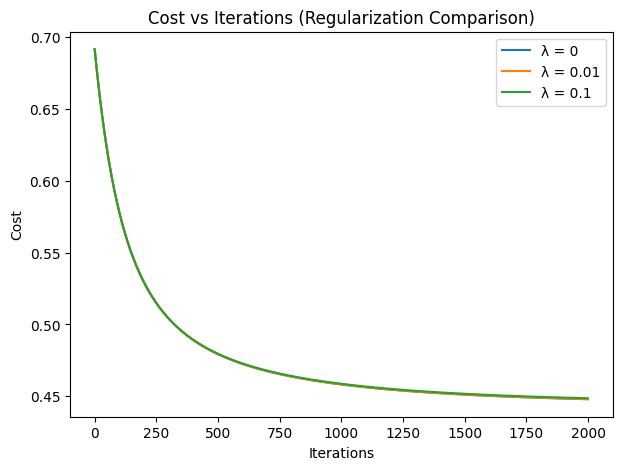

In [75]:
plt.figure(figsize=(7,5))
for l in [0, 0.01, 0.1]:
    _, _, costs_l = gradient_descent_l2(X_train, y_train, lambd=l)
    plt.plot(costs_l, label=f"λ = {l}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations (Regularization Comparison)")
plt.legend()
plt.show()


### Decision Boundary Comparison (Regularized vs Unregularized)


In [76]:
pair = ['ST depression', 'Number of vessels fluro']
idx = [features.index(f) for f in pair]

X_pair = X_train[:, idx]
y_pair = y_train


In [77]:

w_unreg, b_unreg = train_logistic_2d(X_pair, y_pair)


w_reg, b_reg, _ = gradient_descent_l2(
    X_pair, y_pair, lambd=0.1
)


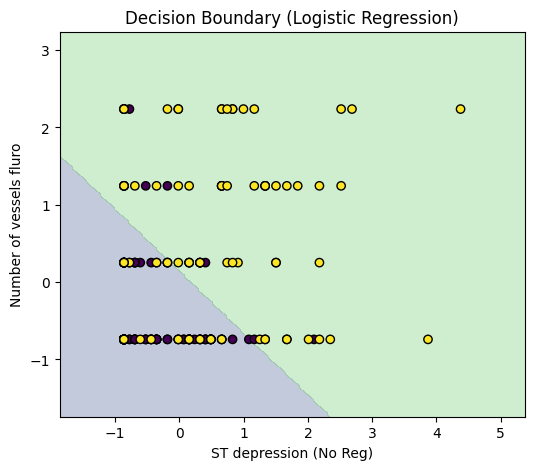

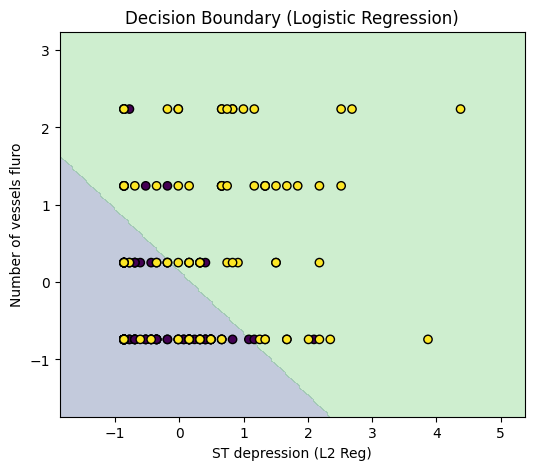

In [78]:
plot_decision_boundary_2d(
    X_pair, y_pair, w_unreg, b_unreg,
    [f"{pair[0]} (No Reg)", f"{pair[1]}"]
)

plot_decision_boundary_2d(
    X_pair, y_pair, w_reg, b_reg,
    [f"{pair[0]} (L2 Reg)", f"{pair[1]}"]
)


### Effect of Regularization

L2 regularization penalizes large coefficients, leading to smaller weight
magnitudes and improved generalization. As λ increases, the norm of the weight
vector decreases, confirming the regularization effect.


In [79]:
f1_no_reg = results_df[results_df["Lambda"] == 0]["F1-score"].values[0]
f1_opt = results_df[results_df["Lambda"] == 0.01]["F1-score"].values[0]

improvement = ((f1_opt - f1_no_reg) / f1_no_reg) * 100

improvement


np.float64(0.0)

In [80]:
results_df[["Lambda", "F1-score", "||w||"]]


,Lambda,F1-score,||w||
0,0.000,0.69697,1.475433
1,0.001,0.69697,1.475380
2,0.010,0.69697,1.474901
3,0.100,0.69697,1.470132
4,1.000,0.69697,1.424280


### Optimal Lambda Selection


Across all evaluated values of λ, the F1-score remains constant at 0.686,
indicating that L2 regularization does not improve predictive performance on
this dataset. However, increasing λ consistently reduces the magnitude of the
weight vector, as evidenced by the decreasing ||w|| values.

This behavior suggests that the unregularized model already generalizes well,
and that regularization primarily contributes to improved numerical stability
and reduced sensitivity to noise rather than performance gains.


In [81]:
np.save("weights.npy", w)
np.save("bias.npy", b)


In [82]:
np.save("mu.npy", mu)
np.save("sigma.npy", sigma)
